In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv(r'/home/check/DATA/university/yr3, hk1/DS111 - phân tích dữ liệu/Do_an/DS111/Data/Silver/Silver_1.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4724 entries, 0 to 4723
Data columns (total 18 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Country_Code                              4724 non-null   object 
 1   Year                                      4724 non-null   int64  
 2   Partner_Name                              4724 non-null   object 
 3   standard_name                             4724 non-null   object 
 4   Export_USD_Thousand                       4724 non-null   float64
 5   Import_USD_Thousand                       4724 non-null   float64
 6   AHS_Weighted_Average_Percent              4724 non-null   float64
 7   MFN_Weighted_Average_Percent              4724 non-null   float64
 8   AHS_Duty_Free_Tariff_Lines_Share_Percent  4724 non-null   float64
 9   has_RCA                                   4724 non-null   int64  
 10  has_Country_Growth                  

# Định nghĩa feature:

- **Partner Name:** This feature represents the name of the trading partner or country with which import and export data is being measured

- **Year:** This feature specifies the specific year for which the import and export data is recorded

- **Export (US$ Thousand):** This feature represents the total value of goods and products exported by the country in thousands of US dollars

- **Import (US$ Thousand):** Similar to exports, this feature represents the total value of goods and products imported by the country in thousands of US dollars

- **AHS Weighted Average (%)**: This feature represents the weighted average tariff rate applied by the country based on the Harmonized System (AHS) classification of products

- **MFN Weighted Average (%):** Similar to the previous feature, this one represents the weighted average most-favored-nation (MFN) tariff rate applied by the country

- **AHS Duty Free Tariff Lines Share (%):** Similar to the previous feature, this one represents the percentage of tariff lines for which no duties are applied.

### AHS (Applied Harmonized System) vs. MFN (Most Favored Nation):

- AHS là mức thuế quan thực tế áp dụng (effectively applied tariffs), bao gồm các ưu đãi thực tế từ thỏa thuận song phương hoặc khu vực (như FTA), thường thấp hơn hoặc bằng MFN. Nó phản ánh tariff mà hàng hóa thực sự phải chịu khi nhập khẩu.

- MFN là mức thuế quan tiêu chuẩn (base rate) mà các thành viên WTO áp dụng cho nhau, không bao gồm ưu đãi đặc biệt. Đây là mức "cao nhất" (highest tariffs) mà một quốc gia áp dụng cho đối tác không ưu đãi, thường dùng làm giới hạn (bound rates) trong đàm phán WTO. MFN tính trên tất cả tariff lines (kể cả không traded), trong khi AHS chỉ trên traded items.

### Simple Average: 
- Đây là trung bình cộng đơn giản của tất cả các dòng thuế quan (tariff lines), nơi mỗi dòng được coi là bằng nhau mà không xem xét đến trọng số. Ví dụ, nếu có ba dòng thuế quan với mức 10%, 20%, và 50%, simple average sẽ là (10 + 20 + 50)/3 = 26.67%. Phương pháp này đơn giản nhưng có thể bị "kéo lệch" bởi các dòng thuế cao trên hàng hóa ít nhập khẩu, dẫn đến đánh giá không chính xác về mức độ bảo hộ tổng thể. Nó thường được sử dụng để so sánh tổng quát giữa các quốc gia hoặc sản phẩm, nhưng không phản ánh tác động kinh tế thực tế vì bỏ qua khối lượng thương mại.

### Weighted Average: 
- Đây là trung bình có trọng số, thường dựa trên giá trị nhập khẩu (import value) của từng dòng thuế quan. Các dòng thuế trên hàng hóa nhập khẩu nhiều hơn sẽ có trọng số lớn hơn, làm cho kết quả phản ánh sát thực tế hơn. Ví dụ, nếu dòng thuế 10% áp dụng cho hàng hóa nhập khẩu trị giá 100 triệu USD, còn 50% chỉ áp dụng cho 1 triệu USD, weighted average sẽ gần với 10% hơn. Phương pháp này đo lường mức độ bảo hộ thực sự (protection applied), vì nó tập trung vào các sản phẩm có tác động lớn đến thương mại. Weighted average thường thấp hơn simple average nếu các hàng hóa có thuế cao bị hạn chế nhập khẩu (do thuế cao làm giảm trade volume).

### Lý do chỉ chọn AHS Duty Free (Tariff Lines Share hoặc Imports) mà không chọn MFN:
1. Tính thực tế và liên quan đến dự đoán: AHS phản ánh tariff áp dụng thực tế (applied rates), nên sát với dữ liệu thương mại thực (imports/exports). MFN là mức lý thuyết (bound hoặc standard), thường cao hơn và không luôn áp dụng (do ưu đãi), nên ít dự đoán được tác động thực tế đến tăng trưởng thương mại hoặc RCA. Ví dụ, nếu một quốc gia có MFN cao nhưng áp dụng AHS thấp nhờ FTA, thì AHS sẽ dự đoán tốt hơn về dòng chảy thương mại tự do (duty free).

2. Đo lường mức độ mở cửa: Duty Free Tariff Lines Share (%) (AHS) cho thấy phần trăm dòng thuế miễn phí thực tế, trực tiếp liên quan đến việc khuyến khích nhập khẩu (cao hơn → mở cửa hơn, tăng imports/exports). Giá trị Duty Free Imports (US$ Thousand) dưới AHS cũng phản ánh khối lượng hàng miễn thuế thực tế. MFN duty free ít biến thiên hơn vì nó là base rate, không capture ưu đãi động (như trong WTO negotiations).

3. Tránh redundancy: MFN thường là "ceiling" (giới hạn trên), trong khi AHS là "floor" (thực tế thấp hơn). Chọn AHS giúp mô hình tập trung vào dữ liệu thực tế, giảm multicollinearity (vì MFN và AHS thường tương quan cao). Nếu cần so sánh, có thể engineer feature như "AHS - MFN differential" thay vì chọn cả hai.

4. Khả năng dự đoán mạnh hơn: AHS dựa trên traded items, nên dự đoán tốt hơn cho các target như Country Growth hoặc RCA (vì phản ánh thương mại thực). MFN phù hợp hơn cho phân tích đàm phán, không phải dự đoán kinh tế thực tế.

In [4]:
df = df[['standard_name','AHS Duty Free Tariff Lines Share (%)','Year','Export (US$ Thousand)','Import (US$ Thousand)','AHS Weighted Average (%)','MFN Weighted Average (%)','has_RCA','has_Country_Growth']]

KeyError: "['AHS Duty Free Tariff Lines Share (%)', 'Export (US$ Thousand)', 'Import (US$ Thousand)', 'AHS Weighted Average (%)', 'MFN Weighted Average (%)'] not in index"

In [ ]:
df.describe()

,AHS Duty Free Tariff Lines Share (%),Year,Export (US$ Thousand),Import (US$ Thousand),AHS Weighted Average (%),MFN Weighted Average (%),has_RCA,has_Country_Growth
count,18724.000000,18732.000000,1.873200e+04,1.873200e+04,18724.000000,18724.000000,18732.000000,18732.000000
mean,58.134417,2009.888693,1.408898e+08,1.306796e+08,5.070397,9.466549,0.769272,0.744928
std,18.628710,6.996109,5.892822e+08,5.603143e+08,4.675614,4.863941,0.421310,0.435913
min,0.000000,1996.000000,0.000000e+00,3.800000e-01,0.000000,1.770000,0.000000,0.000000
25%,43.060000,2004.000000,1.780722e+06,8.152053e+05,1.830000,6.150000,1.000000,0.000000
50%,60.190000,2010.000000,8.690955e+06,5.217768e+06,4.100000,8.540000,1.000000,1.000000
75%,73.040000,2016.000000,5.045161e+07,4.741276e+07,6.790000,11.860000,1.000000,1.000000
max,100.000000,2021.000000,8.895000e+09,8.008408e+09,52.210000,49.080000,1.000000,1.000000


In [ ]:
df.drop_duplicates(inplace=True)

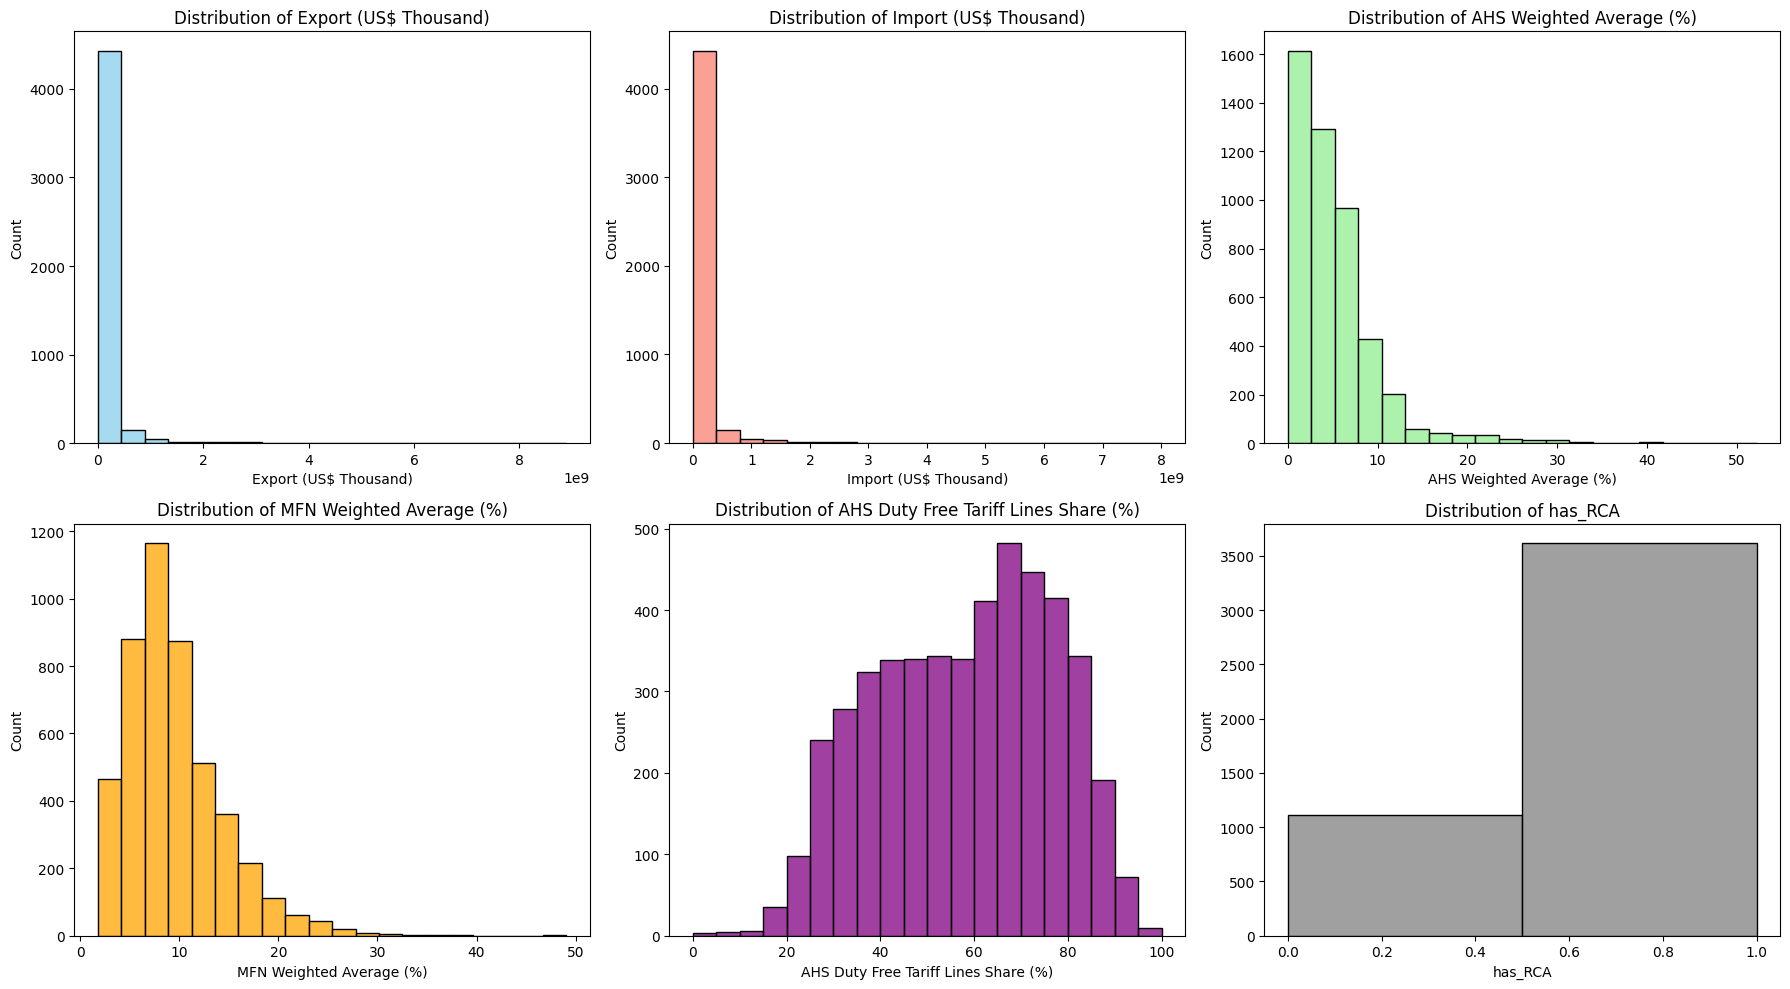

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18,10))
sns.histplot(data=df, x='Export (US$ Thousand)', bins=20, ax=axes[0,0], color='skyblue').set_title('Distribution of Export (US$ Thousand)')
sns.histplot(data=df, x='Import (US$ Thousand)', bins=20, ax=axes[0,1], color='salmon').set_title('Distribution of Import (US$ Thousand)')
sns.histplot(data=df, x='AHS Weighted Average (%)', bins=20, ax=axes[0,2], color='lightgreen').set_title('Distribution of AHS Weighted Average (%)')
sns.histplot(data=df['MFN Weighted Average (%)'],bins=20, ax=axes[1,0], color='orange').set_title('Distribution of MFN Weighted Average (%)')
sns.histplot(data= df['AHS Duty Free Tariff Lines Share (%)'], bins=20, ax=axes[1,1], color='purple').set_title('Distribution of AHS Duty Free Tariff Lines Share (%)')
sns.histplot(data=df['has_RCA'], bins=2, ax=axes[1,2], color='grey').set_title('Distribution of has_RCA')
plt.tight_layout()
plt.show()  

In [ ]:
df['Log_Export'] = np.log1p(df['Export (US$ Thousand)'])
df['Log_Import'] = np.log1p(df['Import (US$ Thousand)'])
df['Log_AHS_Weighted_Average'] = np.log1p(df['AHS Weighted Average (%)'])
df['Log_MFN_Weighted_Average'] = np.log1p(df['MFN Weighted Average (%)'])

In [ ]:
df['tariff_gap'] = df['MFN Weighted Average (%)'] - df['AHS Weighted Average (%)']
df['tariff_gap'].describe()

count    4724.000000
mean        4.403817
std         4.232963
min       -31.940000
25%         2.020000
50%         3.635000
75%         6.252500
max        39.050000
Name: tariff_gap, dtype: float64

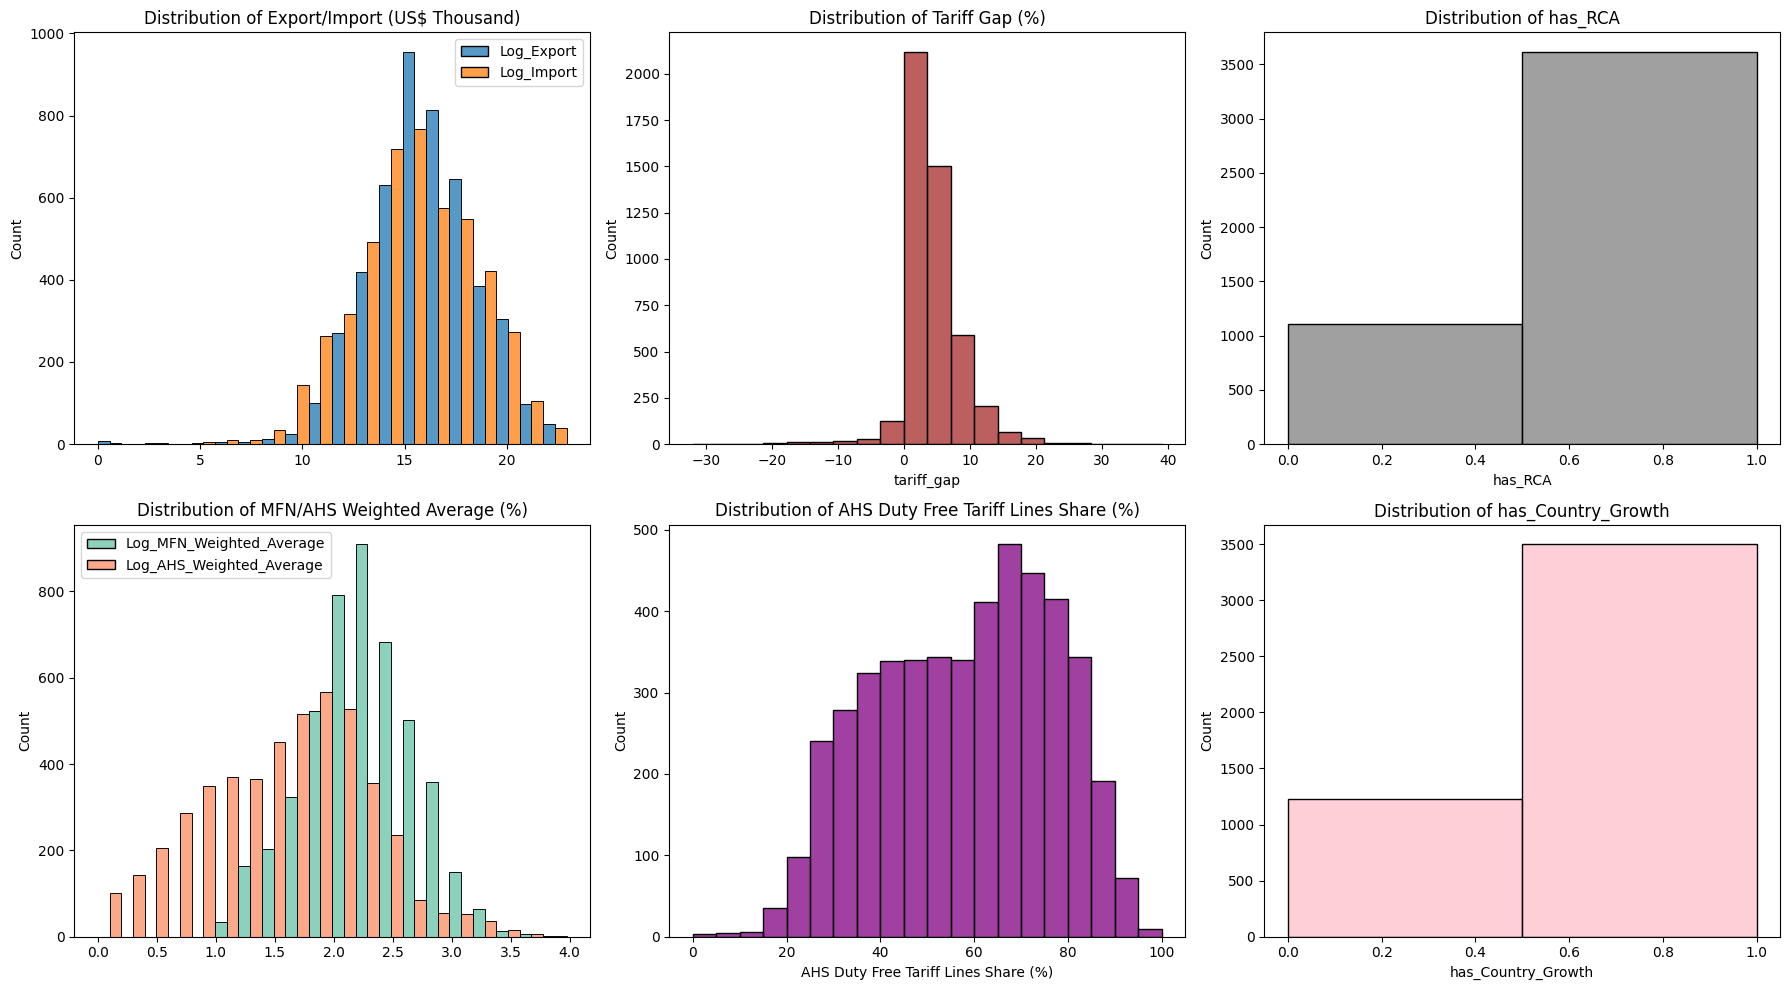

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18,10))
sns.histplot(data=df[['Log_Export','Log_Import']], bins=20, ax=axes[0,0], color='skyblue',multiple='dodge').set_title('Distribution of Export/Import (US$ Thousand)')
sns.histplot(data=df[['Log_MFN_Weighted_Average','Log_AHS_Weighted_Average']],bins=20, ax=axes[1,0],palette='Set2',multiple='dodge').set_title('Distribution of MFN/AHS Weighted Average (%)')
sns.histplot(data= df['AHS Duty Free Tariff Lines Share (%)'], bins=20, ax=axes[1,1], color='purple').set_title('Distribution of AHS Duty Free Tariff Lines Share (%)')
sns.histplot(data=df['has_RCA'], bins=2, ax=axes[0,2], color='grey').set_title('Distribution of has_RCA')
sns.histplot(data=df, x='tariff_gap', bins=20, ax=axes[0,1], color='brown').set_title('Distribution of Tariff Gap (%)')
sns.histplot(data=df['has_Country_Growth'], bins=2, ax=axes[1,2], color='pink').set_title('Distribution of has_Country_Growth')
plt.tight_layout()
plt.show()  

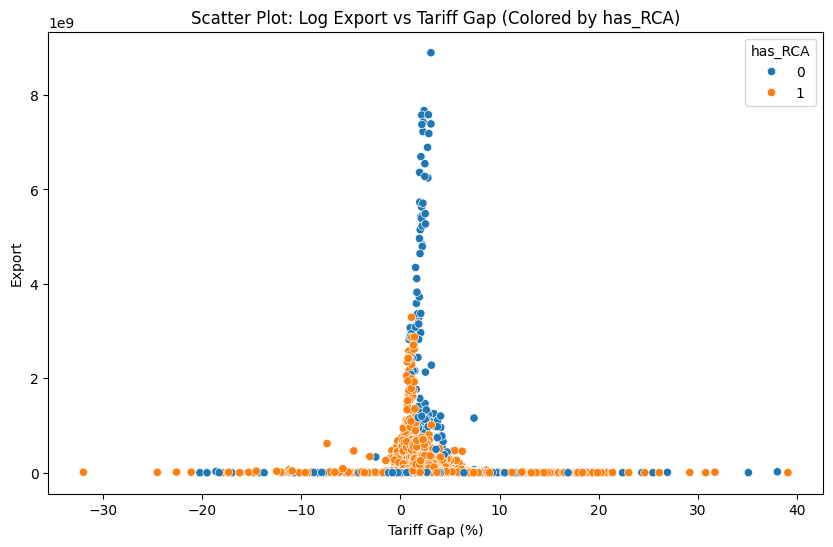

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='tariff_gap', y='Export (US$ Thousand)', hue='has_RCA', data=df)
plt.title('Scatter Plot: Log Export vs Tariff Gap (Colored by has_RCA)')
plt.xlabel('Tariff Gap (%)')
plt.ylabel('Export')
plt.show()

In [ ]:
df.drop(columns=['Export (US$ Thousand)','Import (US$ Thousand)','AHS Weighted Average (%)','MFN Weighted Average (%)'], inplace=True)

Text(0.5, 0, 'Tariff Gap (%)')

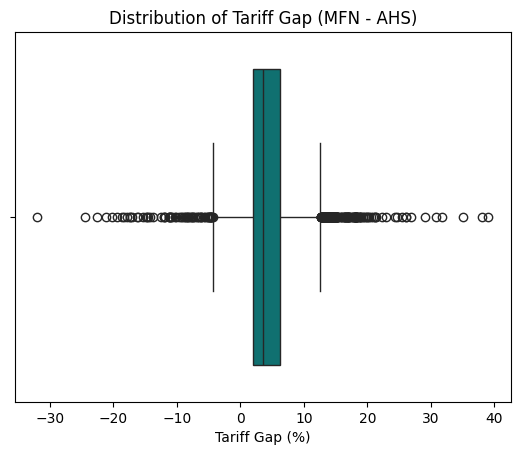

In [ ]:
sns.boxplot(data=df, x='tariff_gap', color='teal')
plt.title('Distribution of Tariff Gap (MFN - AHS)')
plt.xlabel('Tariff Gap (%)')

In [ ]:
df.columns

Index(['standard_name', 'AHS Duty Free Tariff Lines Share (%)', 'Year',
       'has_RCA', 'has_Country_Growth', 'Log_Export', 'Log_Import',
       'Log_AHS_Weighted_Average', 'Log_MFN_Weighted_Average', 'tariff_gap'],
      dtype='object')

In [ ]:
df.shape

(4726, 10)

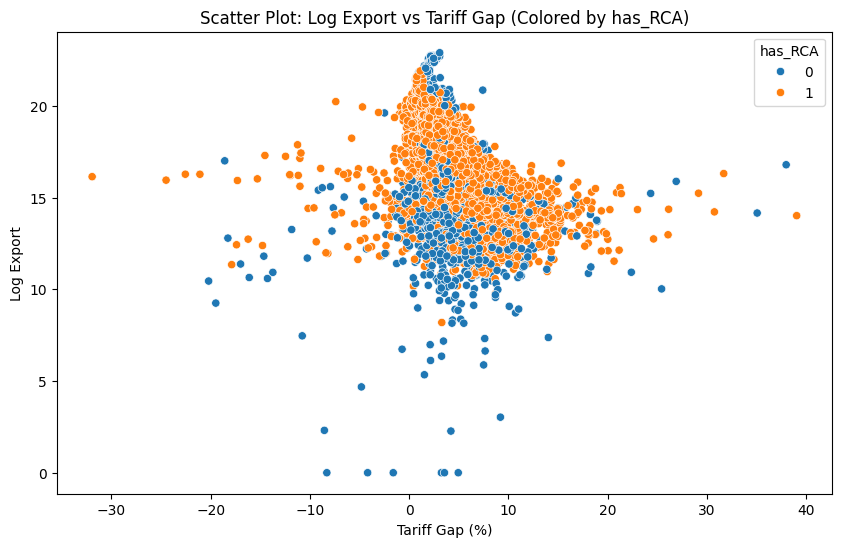

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='tariff_gap', y='Log_Export', hue='has_RCA', data=df)
plt.title('Scatter Plot: Log Export vs Tariff Gap (Colored by has_RCA)')
plt.xlabel('Tariff Gap (%)')
plt.ylabel('Log Export')
plt.show()

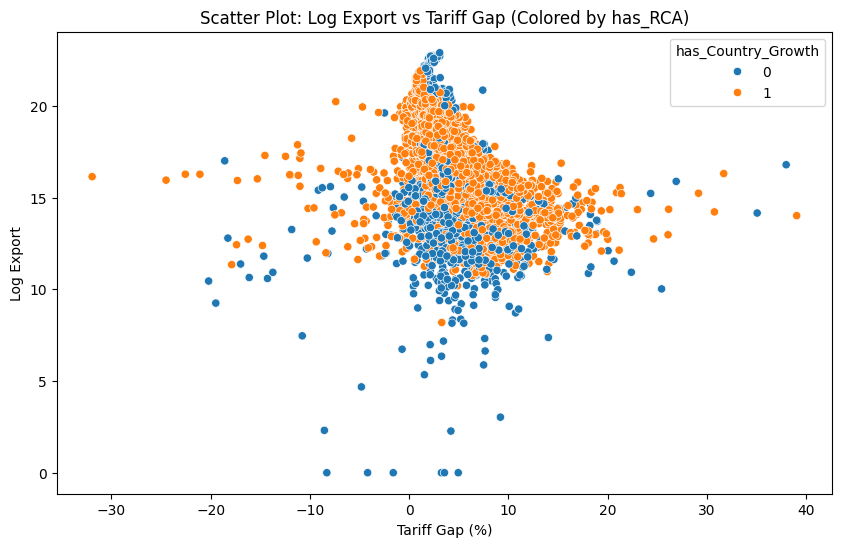

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='tariff_gap', y='Log_Export', hue='has_Country_Growth', data=df)
plt.title('Scatter Plot: Log Export vs Tariff Gap (Colored by has_RCA)')
plt.xlabel('Tariff Gap (%)')
plt.ylabel('Log Export')
plt.show()

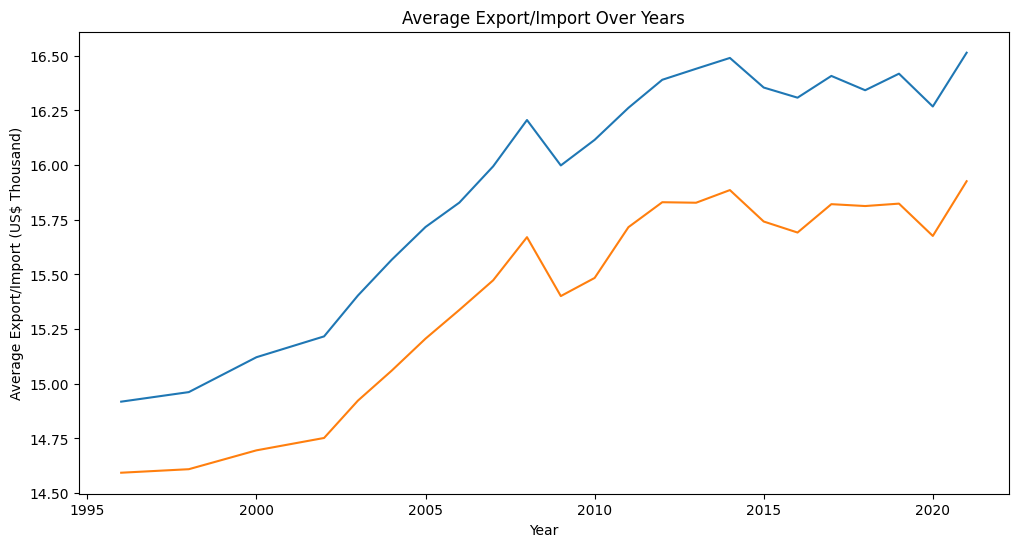

In [ ]:
avg_export_year = df.groupby('Year')['Log_Export'].mean().reset_index()
avg_import_year = df.groupby('Year')['Log_Import'].mean().reset_index()
plt.figure(figsize=(12, 6))
sns.lineplot(x='Year', y='Log_Export', data=avg_export_year)
sns.lineplot(x='Year', y='Log_Import', data=avg_import_year)
plt.title('Average Export/Import Over Years')
plt.xlabel('Year')
plt.ylabel('Average Export/Import (US$ Thousand)')
plt.show()

In [ ]:
selected_cols = ['standard_name', 'AHS Duty Free Tariff Lines Share (%)', 'Year', 'has_RCA', 
                 'Log_Export', 'Log_Import', 'Log_AHS_Weighted_Average', 'Log_MFN_Weighted_Average', 'tariff_gap','has_Country_Growth']

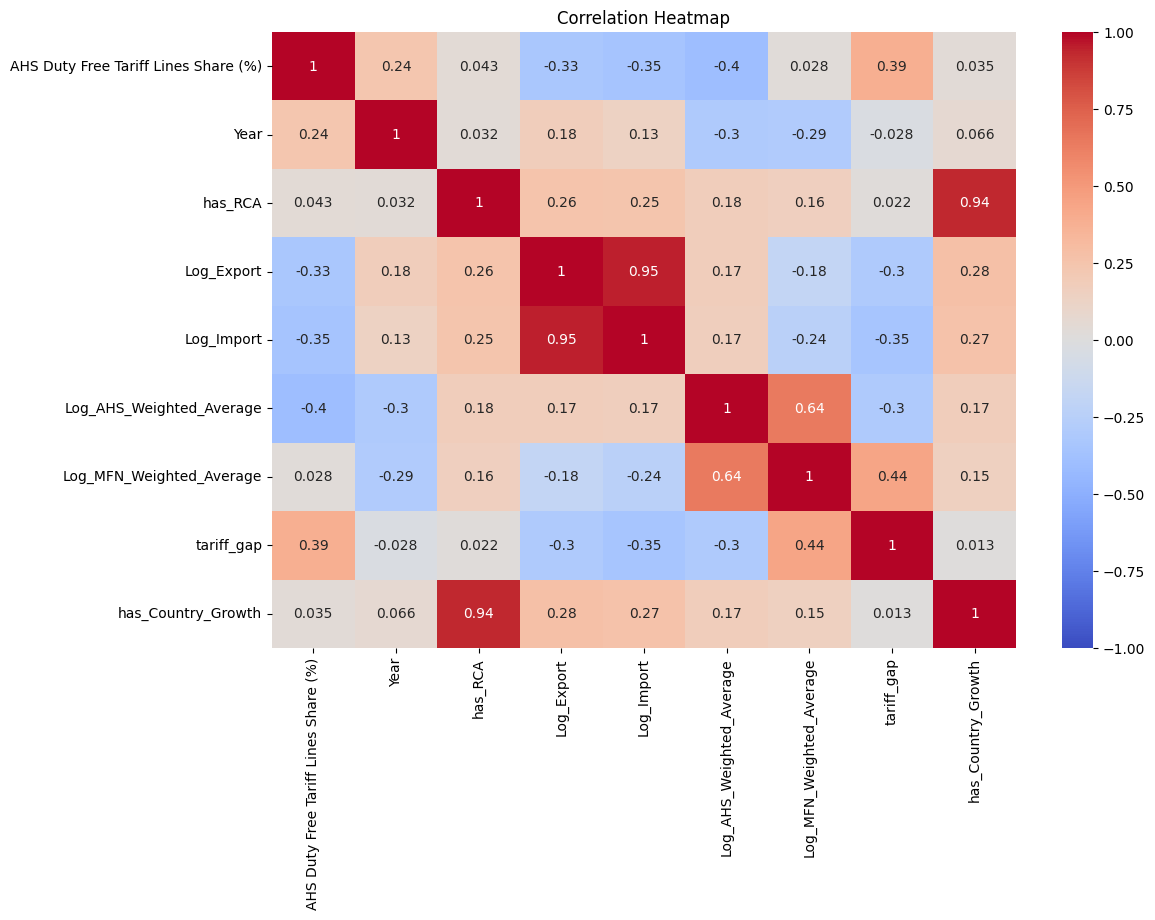

In [ ]:
numeric_df = df[selected_cols].select_dtypes(include=['float64', 'int64'])
corr = numeric_df.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap')
plt.show()

Export/Import (US$ Thousand):
Insight: Corr 0.98 Export/Import → bilateral trade mạnh (pairplot scatter dương tuyến tính), nhưng outliers max cao → nước lớn dominate (groupby 'standard_name' để check USA/China pull mean). Corr dương has_RCA (0.26 Log_Export) → lợi thế so sánh tăng xuất khẩu ~20-30% (kinh tế: Ricardo theory).

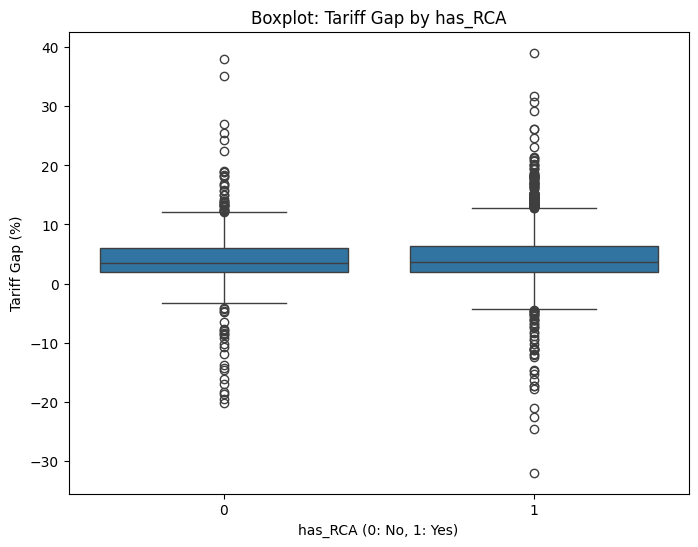

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='has_RCA', y='tariff_gap', data=df)
plt.title('Boxplot: Tariff Gap by has_RCA')
plt.xlabel('has_RCA (0: No, 1: Yes)')
plt.ylabel('Tariff Gap (%)')
plt.show()

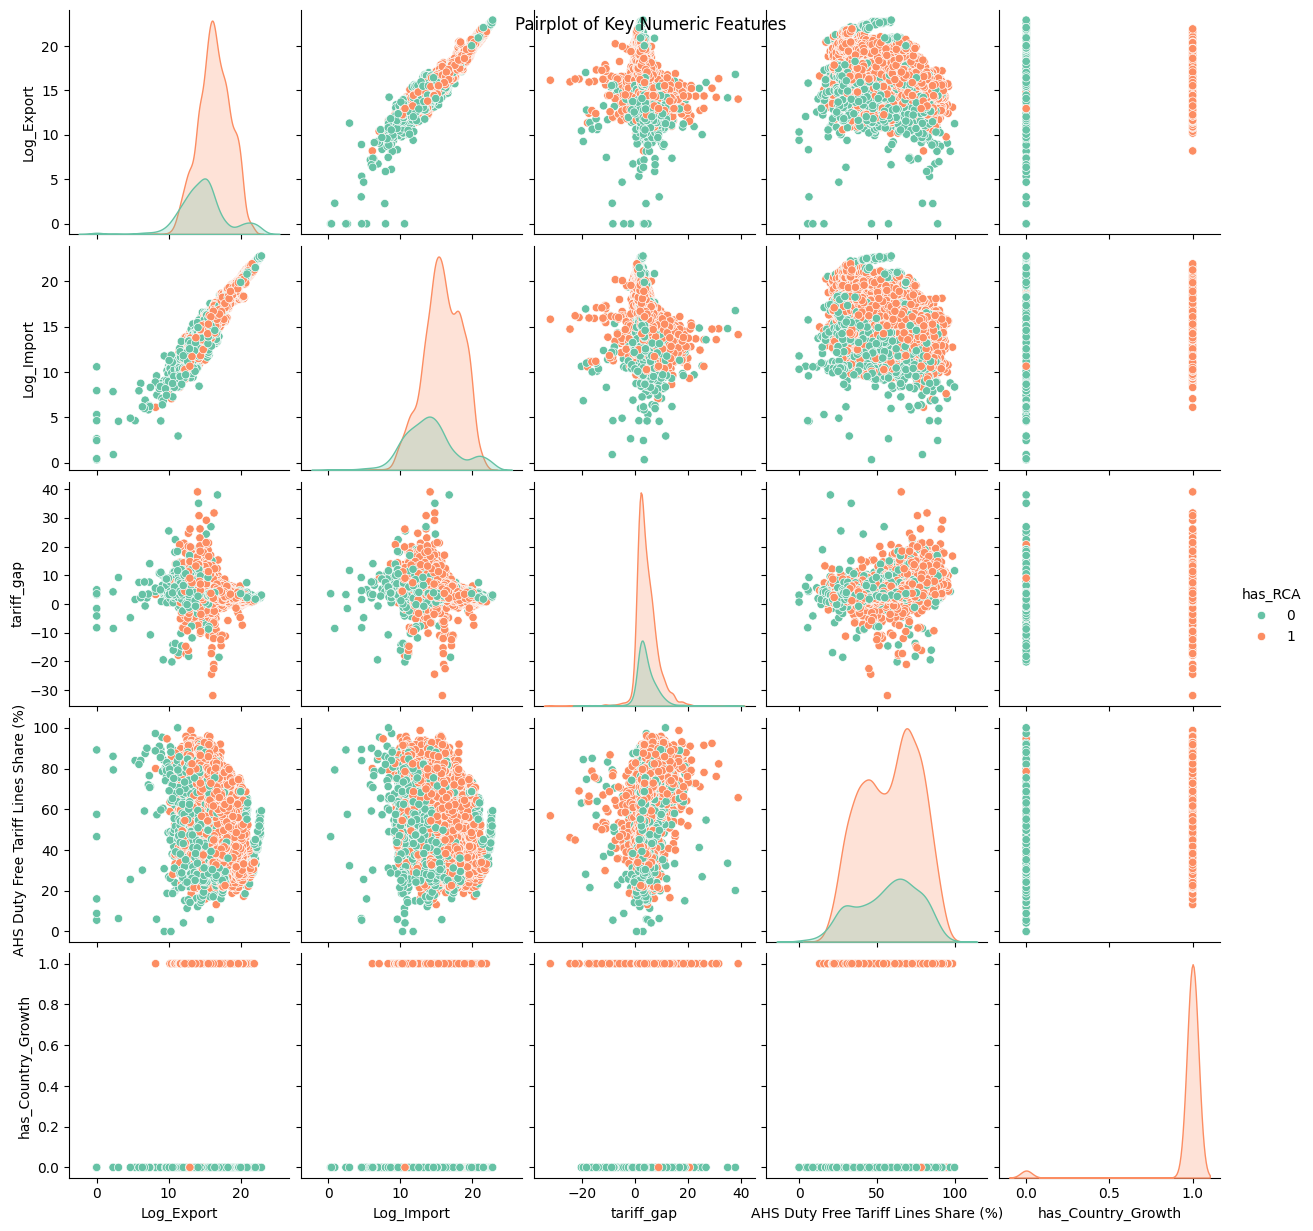

In [ ]:
sns.pairplot(numeric_df, vars=['Log_Export', 'Log_Import', 'tariff_gap', 'AHS Duty Free Tariff Lines Share (%)','has_Country_Growth'], hue='has_RCA', diag_kind='kde', palette='Set2')
plt.suptitle('Pairplot of Key Numeric Features')
plt.show()